In [3]:
%load_ext autoreload
%autoreload 2
%matplotlib inline


In [4]:
import pandas as pd
pd.set_option("display.max_rows", None)
import warnings
warnings.filterwarnings('ignore')


In [5]:

import libs
files = libs.data(subjects=[0],recording=[1])



Using default location ~/mne_data for PHYSIONET_SLEEP...


In [6]:
raw = libs.mne.io.read_raw_edf(files[0][0],preload=True)
print(raw.info)

Extracting EDF parameters from /Users/apple/mne_data/physionet-sleep-data/SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, Resp oro-nasal, EMG ...
 chs: 7 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 50.0 Hz
 meas_date: 1989-04-24 16:13:00 UTC
 nchan: 7
 projs: []
 sfreq: 100.0 Hz
 subject_info: <subject_info | his_id: X, sex: 2, first_name: Female, last_name: 33yr>
>


Using matplotlib as 2D backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


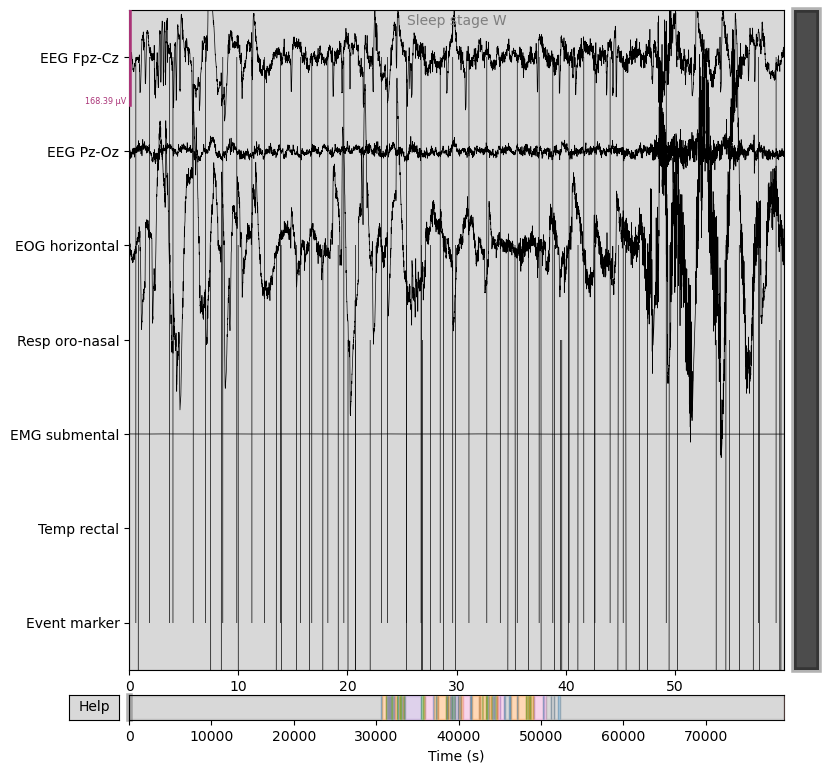

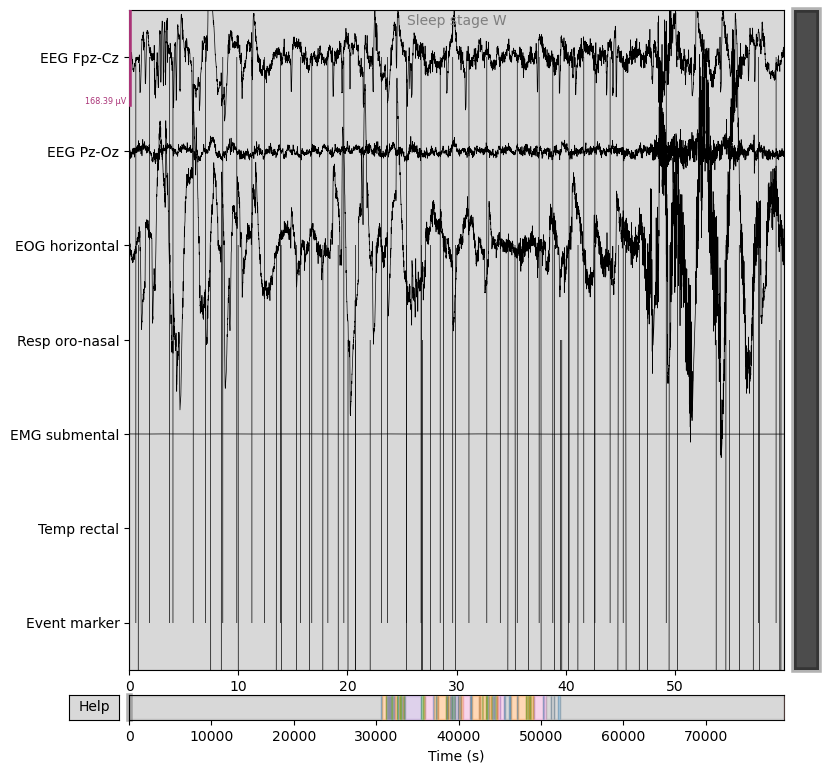

In [7]:
annotations = libs.mne.read_annotations(files[0][1])
raw.set_annotations(annotations)
raw.plot(duration=60, scalings='auto')

In [8]:
events, event_id = libs.mne.events_from_annotations(raw)
print(event_id)

Used Annotations descriptions: ['Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage ?', 'Sleep stage R', 'Sleep stage W']
{'Sleep stage 1': 1, 'Sleep stage 2': 2, 'Sleep stage 3': 3, 'Sleep stage 4': 4, 'Sleep stage ?': 5, 'Sleep stage R': 6, 'Sleep stage W': 7}


In [9]:
epochs=libs.mne.Epochs(raw,events,event_id,tmin=0,tmax=30,baseline=None,preload=True)
print(epochs)

Not setting metadata
154 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 154 events and 3001 original time points ...
1 bad epochs dropped
<Epochs | 153 events (all good), 0 – 30 s (baseline off), ~24.5 MiB, data loaded,
 'Sleep stage 1': 24
 'Sleep stage 2': 40
 'Sleep stage 3': 48
 'Sleep stage 4': 23
 'Sleep stage ?': 0
 'Sleep stage R': 6
 'Sleep stage W': 12>


For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


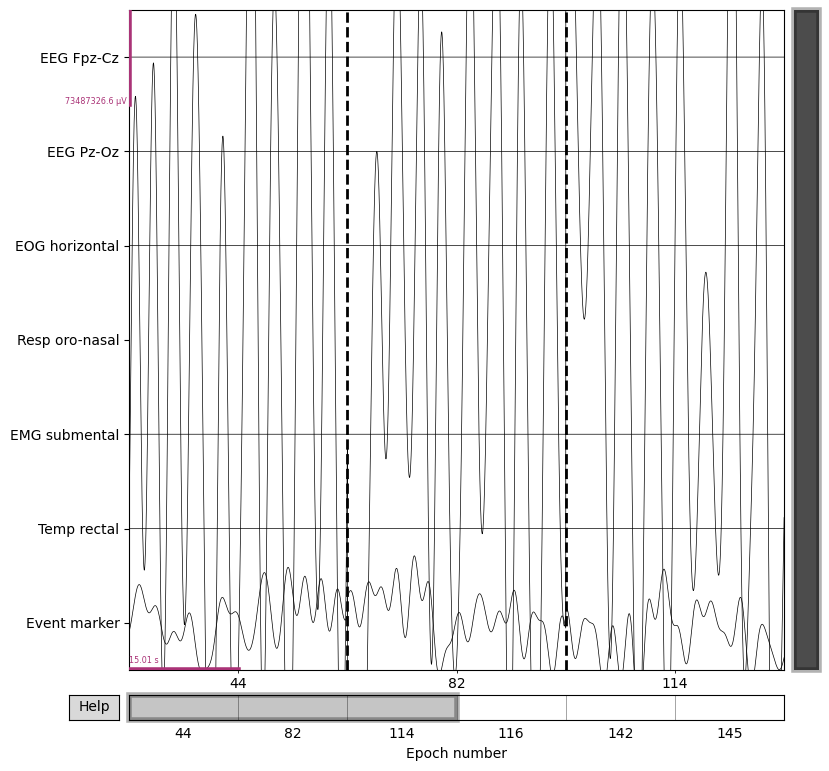

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


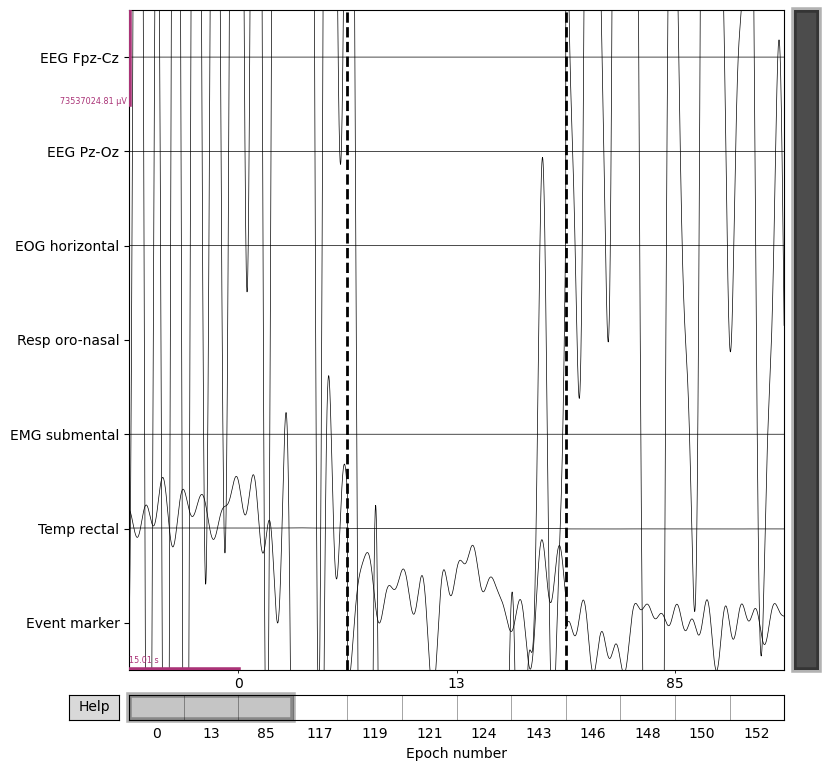

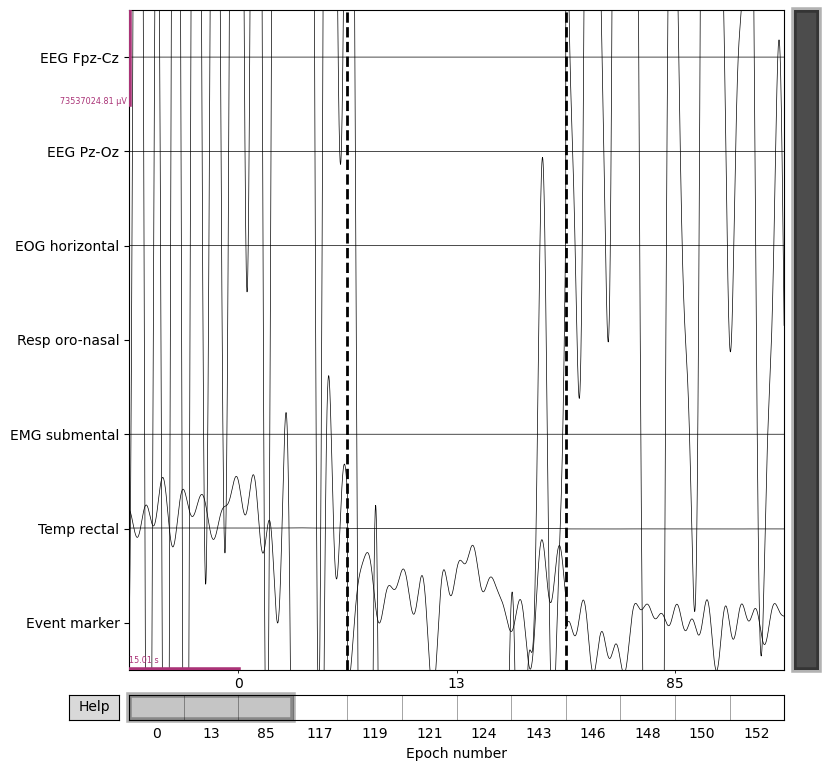

In [10]:
epochs['Sleep stage R'].plot(n_epochs=3, scalings='auto')
epochs['Sleep stage W'].plot(n_epochs=3, scalings='auto')

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


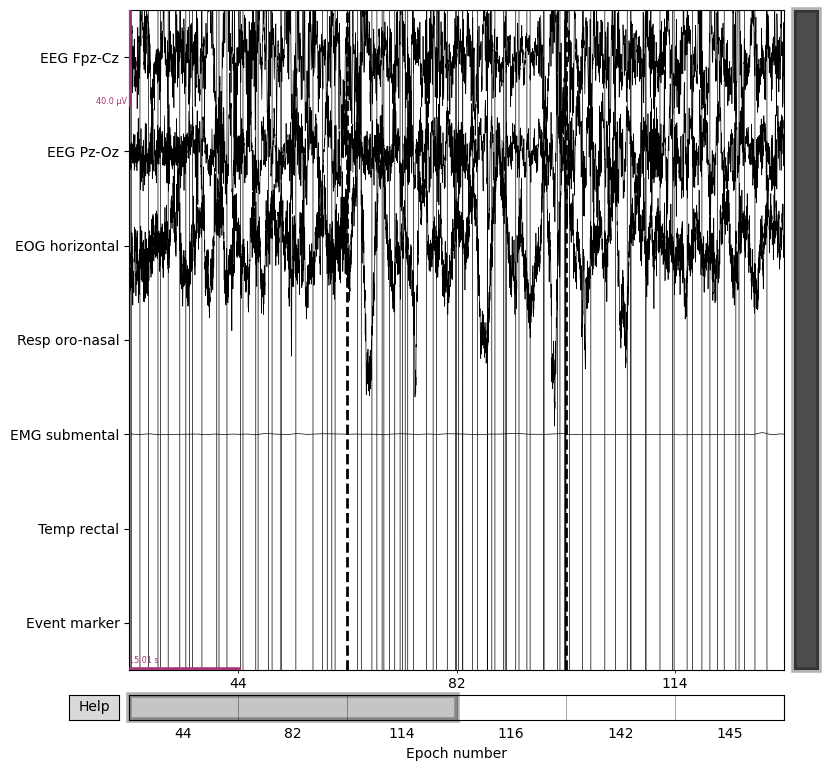

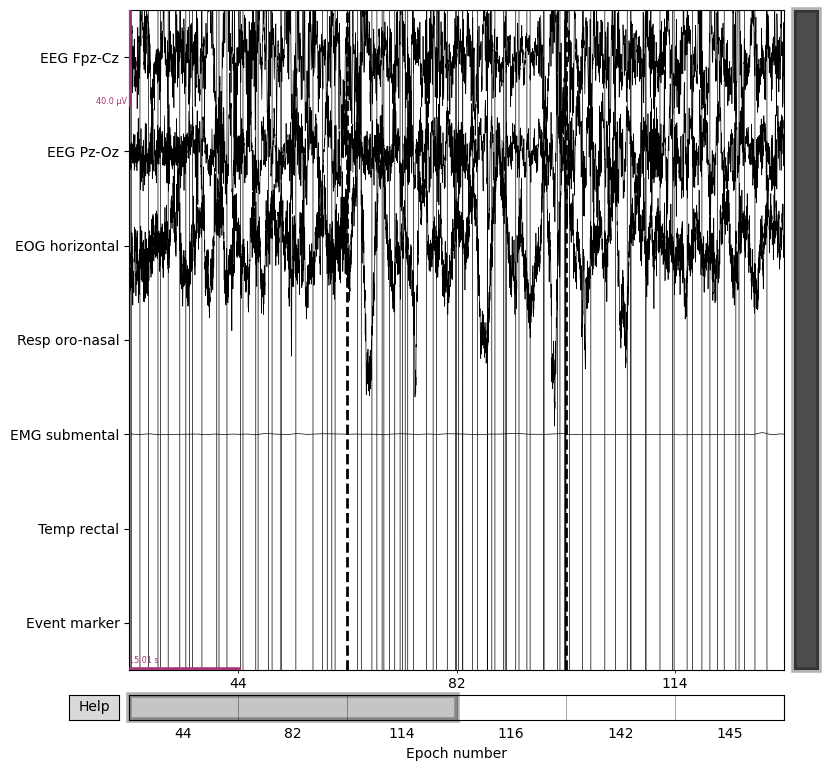

In [11]:
epochs['Sleep stage R'].plot(
    n_epochs=3,
    scalings=dict(eeg=20e-6, eog=150e-6, emg=200e-6)
)

In [12]:
eeg = raw.get_data(
    picks=['EEG Fpz-Cz', 'EEG Pz-Oz']
)

print("EEG min:", eeg.min())
print("EEG max:", eeg.max())

EEG min: -0.000192
EEG max: 0.00019600000000000002


In [13]:
for ch in ['EEG Fpz-Cz', 'EEG Pz-Oz']:
    idx = raw.ch_names.index(ch)
    print(ch, raw.get_data(picks=[idx]).min(), raw.get_data(picks=[idx]).max())

EEG Fpz-Cz -0.000192 0.0001706197802197802
EEG Pz-Oz -0.00017108791208791208 0.00019600000000000002


For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


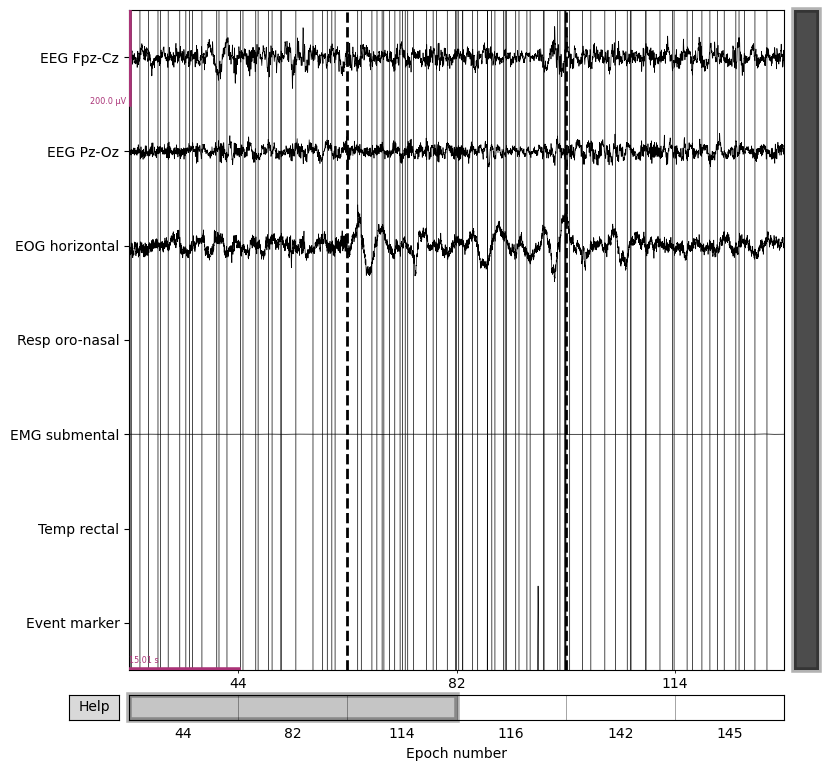

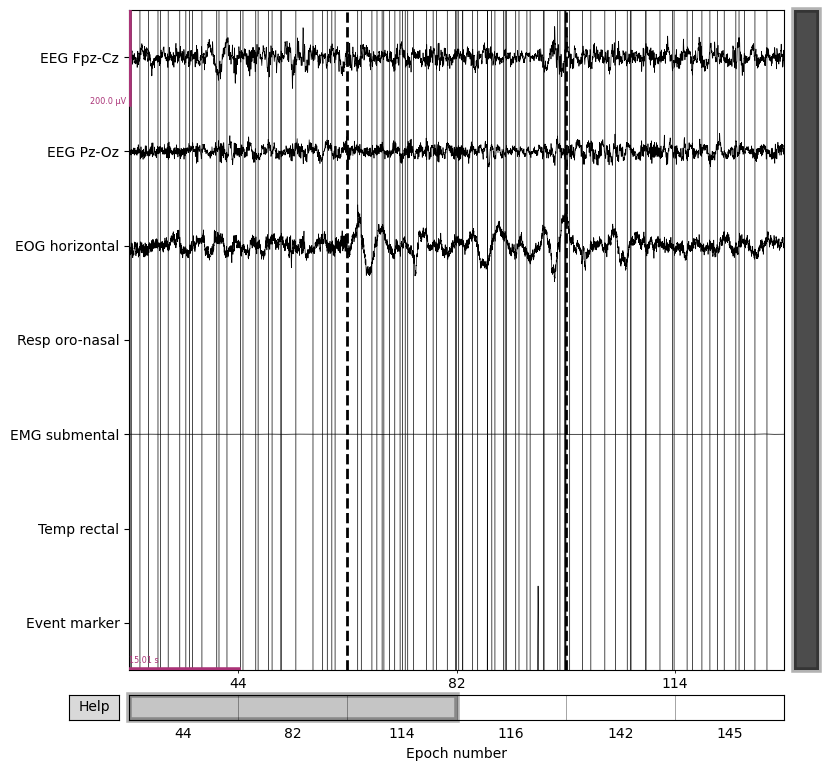

In [14]:
epochs['Sleep stage R'].plot(
    n_epochs=3,
    scalings={
        'eeg': 100e-6,
        'eog': 150e-6,
        'emg': 200e-6,
    }
)

Effective window size : 20.480 (s)
Plotting power spectral density (dB=True).


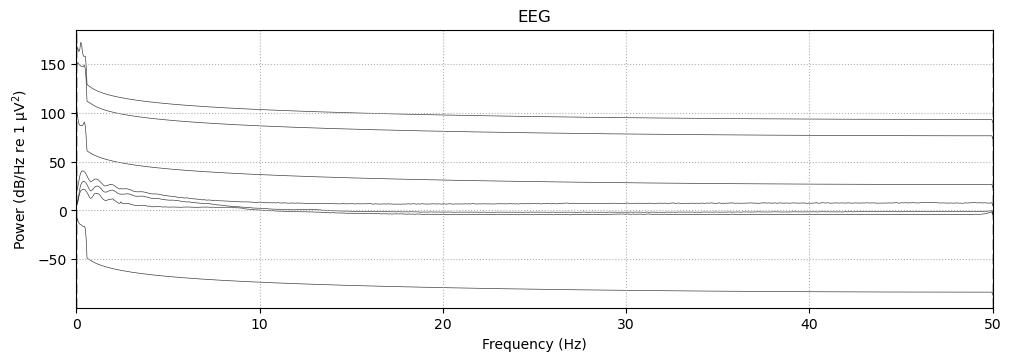

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


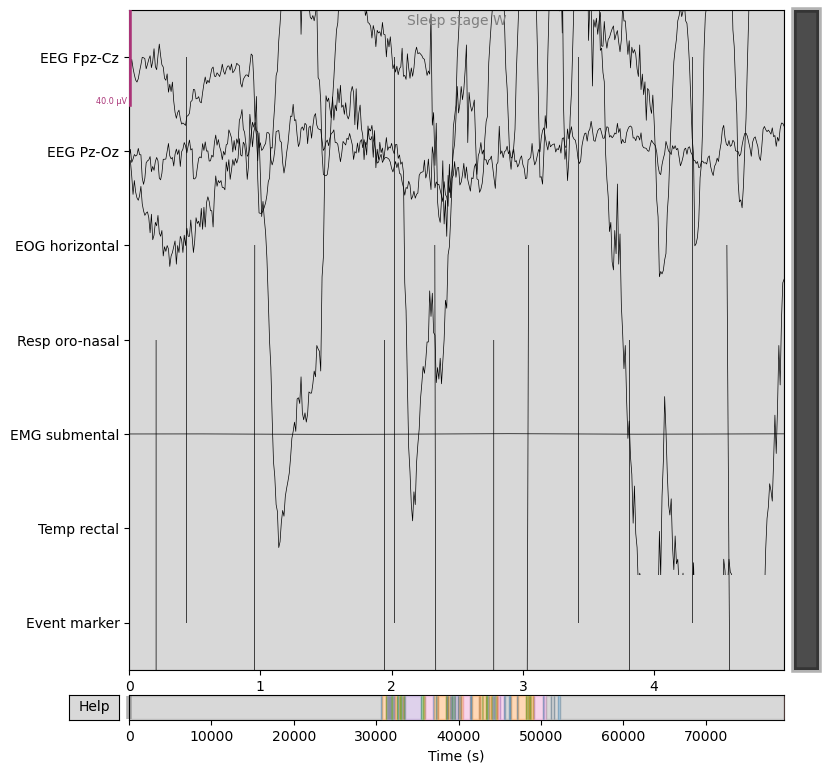

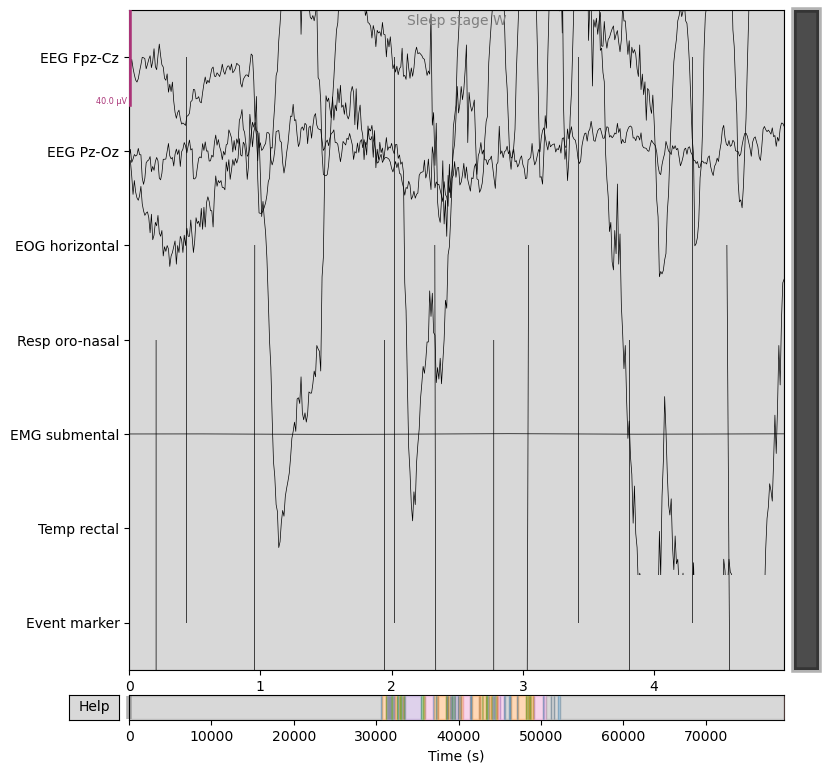

In [16]:
raw.compute_psd(fmax=50).plot(picks="data",exclude="bads",amplitude=False)
raw.plot(duration=5,n_channels=30)